In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.optimize import minimize
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

# =============================================================
# 1. CHARGEMENT ET PRÉPARATION DES DONNÉES
# =============================================================
commo = pd.read_excel('Commo_Strategy_Monthly_Returns.xlsx', sheet_name='3_Facteurs').iloc[:, :2]
commo.columns = ['date', 'Commodity']
commo['date'] = pd.to_datetime(commo['date']).dt.to_period('M').dt.to_timestamp('M')

curr = pd.read_excel('PPP_Pure_Strategy_Returns_EOM_Net.xlsx', sheet_name='PPP_Pure_Net').iloc[:, :2]
curr.columns = ['date', 'Currency']
curr['date'] = pd.to_datetime(curr['date']).dt.to_period('M').dt.to_timestamp('M')

eq_is = pd.read_csv('insample_allocation.csv')
eq_is = eq_is[eq_is['strategy'] == 'C_ValueQualityMom'][['date', 'ls_ret']]
eq_is.columns = ['date', 'Equity']
eq_is['date'] = pd.to_datetime(eq_is['date']).dt.to_period('M').dt.to_timestamp('M')

eq_oos = pd.read_csv('master_allocation.csv')
eq_oos = eq_oos[eq_oos['strategy'] == 'C_ValueQualityMom'][['date', 'ls_ret']]
eq_oos.columns = ['date', 'Equity']
eq_oos['date'] = pd.to_datetime(eq_oos['date']).dt.to_period('M').dt.to_timestamp('M')

equity = pd.concat([eq_is, eq_oos]).drop_duplicates(subset=['date']).sort_values('date')

rates = pd.read_excel('fi_combo_global_quarterly_log_returns.xlsx', sheet_name='Sheet1').iloc[:, :2]
rates.columns = ['date', 'Rate']
rates['date'] = pd.to_datetime(rates['date']).dt.to_period('M').dt.to_timestamp('M')

macro = pd.read_csv('macro_regimes.csv').iloc[:, :2]
macro.columns = ['date', 'regime']
macro['date'] = pd.to_datetime(macro['date']).dt.to_period('M').dt.to_timestamp('M')

# =====================

In [2]:
#========================================
# 2. FUSION ET CONVERSIONS
# =============================================================
df = equity.merge(commo, on='date', how='inner') \
           .merge(curr, on='date', how='inner') \
           .merge(rates, on='date', how='inner') \
           .merge(macro, on='date', how='inner')

df.set_index('date', inplace=True)
df.sort_index(inplace=True)

df['Commodity'] = np.exp(df['Commodity']) - 1
df['Currency']  = np.exp(df['Currency'])  - 1
df['Rate']      = np.exp(df['Rate'])      - 1

# FIX 1: No date overlap — 2014-12-31 belongs to IS only
df_is  = df.loc[:'2014-12-31'].copy()
df_oos = df.loc['2015-01-31':].copy()

assets    = ['Equity', 'Rate', 'Currency', 'Commodity']
tc_array  = np.array([0.0050, 0.0010, 0.0010, 0.0020])

# FIX 2: Deterministic regime order — no more silent reshuffling across runs
regimes = sorted(df['regime'].unique())

print("\n--- MATRICE DE CORRÉLATION (1998 - 2024) ---")
print(df[assets].corr().round(3))
print("-" * 45)
print(f"\nIS  : {df_is.index[0].date()}  →  {df_is.index[-1].date()}  ({len(df_is)} mois)")
print(f"OOS : {df_oos.index[0].date()} →  {df_oos.index[-1].date()}  ({len(df_oos)} mois)")
print(f"\nRégimes (ordre fixe) : {regimes}")



--- MATRICE DE CORRÉLATION (1998 - 2024) ---
           Equity   Rate  Currency  Commodity
Equity      1.000 -0.063    -0.070     -0.010
Rate       -0.063  1.000    -0.125      0.129
Currency   -0.070 -0.125     1.000     -0.019
Commodity  -0.010  0.129    -0.019      1.000
---------------------------------------------

IS  : 1998-01-31  →  2014-12-31  (204 mois)
OOS : 2015-01-31 →  2024-10-31  (118 mois)

Régimes (ordre fixe) : ['crisis', 'goldilocks', 'reflation', 'slowdown', 'stagflation']


In [3]:

# =============================================================
# 3. FONCTION DE CALCUL DES RETURNS NETS
# FIX 3: init_weights parameter — OOS can pass IS terminal weights
#         so the first rebalancing TC is correctly computed
# =============================================================
def calc_net_returns(weights_flat, df_subset, init_weights=None):
    """
    weights_flat : 1-D array of shape (n_regimes * n_assets,)
                   Row order matches `regimes` (sorted, deterministic).
    df_subset    : DataFrame with columns = assets + 'regime'
    init_weights : weights held before period starts (for TC on first trade).
                   Defaults to the first period's target if None.
    """
    w_df = pd.DataFrame(
        weights_flat.reshape(len(regimes), len(assets)),
        index=regimes, columns=assets
    )
    n = len(df_subset)
    net_ret = np.zeros(n)

    target_weights_mat = np.array([w_df.loc[r] for r in df_subset['regime']])
    ret_mat            = df_subset[assets].values

    current_weights = init_weights if init_weights is not None else target_weights_mat[0]

    for i in range(n):
        target_w  = target_weights_mat[i]
        ret       = ret_mat[i]
        turnover  = np.abs(target_w - current_weights)
        tc_cost   = np.sum(turnover * tc_array)
        gross_ret = np.sum(target_w * ret)
        net_ret[i] = gross_ret - tc_cost
        # drift weights forward
        current_weights = target_w * (1 + ret) / (1 + gross_ret)

    return net_ret, current_weights   # also return terminal weights

#

In [4]:
# =============================================================
# 4. OBJECTIF: SHARPE + RENDEMENT (Score Composite)
# =============================================================
def custom_objective(weights_flat, df_subset, init_weights=None):
    net_ret, _ = calc_net_returns(weights_flat, df_subset, init_weights)
    std = np.std(net_ret)
    if std == 0:
        return 0
    sharpe  = (np.mean(net_ret) / std) * np.sqrt(12)
    ann_ret = (1 + np.mean(net_ret)) ** 12 - 1
    lambda_ret = 5.0   # 1% extra return compensates 0.05 loss in Sharpe
    return -(sharpe + lambda_ret * ann_ret)

n_regimes = len(regimes)
n_assets  = len(assets)

initial_weights = np.full(n_regimes * n_assets, 1.0 / n_assets)
bounds          = [(0.10, 0.50)] * (n_regimes * n_assets)
constraints     = [
    {'type': 'eq', 'fun': lambda w, i=i: np.sum(w[i * n_assets:(i + 1) * n_assets]) - 1.0}
    for i in range(n_regimes)
]

print("\nOptimisation In-Sample en cours …")
res = minimize(
    custom_objective, initial_weights,
    args=(df_is,),
    bounds=bounds, constraints=constraints, method='SLSQP'
)

opt_weights_df = pd.DataFrame(
    res.x.reshape(n_regimes, n_assets),
    index=regimes, columns=assets
)

print(f"Convergence : {'✓' if res.success else '✗'}  ({res.message})")
print("\n--- PONDÉRATIONS OPTIMALES PAR RÉGIME ---")
print((opt_weights_df * 100).round(2).astype(str) + ' %')

# =============================================================
# 5. PASSIF VS ACTIF  —  IS et OOS
# FIX 3 (continued): pass IS terminal weights into OOS evaluation
# =============================================================
passive_flat = np.tile(1.0 / n_assets, n_regimes * n_assets)

df_is['Passive'],  _           = calc_net_returns(passive_flat, df_is)
df_is['Active'],   is_terminal = calc_net_returns(res.x,        df_is)

# OOS starts from where IS left off (correct TC on first OOS trade)
df_oos['Passive'], _  = calc_net_returns(passive_flat, df_oos, init_weights=np.tile(0.25, n_assets))
df_oos['Active'],  _  = calc_net_returns(res.x,        df_oos, init_weights=is_terminal)



Optimisation In-Sample en cours …
Convergence : ✓  (Optimization terminated successfully)

--- PONDÉRATIONS OPTIMALES PAR RÉGIME ---
              Equity     Rate Currency Commodity
crisis        10.0 %   31.9 %  45.64 %   12.47 %
goldilocks   15.57 %  44.02 %  30.41 %    10.0 %
reflation    15.89 %   50.0 %   10.0 %   24.11 %
slowdown     31.17 %  44.44 %  11.76 %   12.63 %
stagflation  18.48 %  41.65 %  10.18 %   29.69 %


In [5]:

# =============================================================
# 6. MÉTRIQUES
# =============================================================
def get_metrics(returns):
    ann_ret = (1 + returns).prod() ** (12 / len(returns)) - 1
    ann_vol = returns.std() * np.sqrt(12)
    sharpe  = ann_ret / ann_vol if ann_vol != 0 else 0
    cum_ret = (1 + returns).cumprod()
    max_dd  = ((cum_ret - cum_ret.cummax()) / cum_ret.cummax()).min()
    calmar  = ann_ret / abs(max_dd) if max_dd != 0 else 0
    return pd.Series({
        'Rendement Annualisé'  : f"{ann_ret:.2%}",
        'Volatilité Annualisée': f"{ann_vol:.2%}",
        'Sharpe Ratio'         : f"{sharpe:.2f}",
        'Max Drawdown'         : f"{max_dd:.2%}",
        'Calmar Ratio'         : f"{calmar:.2f}",
        'Skewness'             : f"{stats.skew(returns):.2f}",
        'Kurtosis'             : f"{stats.kurtosis(returns):.2f}",
        'VaR (95%)'            : f"{np.percentile(returns, 5):.2%}",
        'CVaR (95%)'           : f"{returns[returns <= np.percentile(returns, 5)].mean():.2%}",
    })

print("\n--- Métriques NETTES In-Sample (1998 - 2014) ---")
print(pd.DataFrame({'Passif': get_metrics(df_is['Passive']),
                    'Actif' : get_metrics(df_is['Active'])}))

print("\n--- Métriques NETTES Out-Of-Sample (2015 - 2024) ---")
print(pd.DataFrame({'Passif': get_metrics(df_oos['Passive']),
                    'Actif' : get_metrics(df_oos['Active'])}))



--- Métriques NETTES In-Sample (1998 - 2014) ---
                       Passif   Actif
Rendement Annualisé     5.06%   5.67%
Volatilité Annualisée   3.95%   3.70%
Sharpe Ratio             1.28    1.53
Max Drawdown           -6.82%  -4.20%
Calmar Ratio             0.74    1.35
Skewness                 0.10   -0.01
Kurtosis                 1.14    0.76
VaR (95%)              -1.42%  -1.53%
CVaR (95%)             -2.03%  -2.00%

--- Métriques NETTES Out-Of-Sample (2015 - 2024) ---
                        Passif   Actif
Rendement Annualisé      3.43%   3.47%
Volatilité Annualisée    4.22%   3.67%
Sharpe Ratio              0.81    0.94
Max Drawdown           -11.98%  -6.68%
Calmar Ratio              0.29    0.52
Skewness                 -0.55    0.06
Kurtosis                  1.16    0.02
VaR (95%)               -1.89%  -1.36%
CVaR (95%)              -2.72%  -1.90%


In [6]:

# =============================================================
# 7. ANALYSE PAR RÉGIME (OOS)
# =============================================================
print("\n--- Rendement moyen mensuel NET par régime (OOS) ---")
regime_perf = df_oos.groupby('regime')[['Passive', 'Active']].mean()
regime_perf.columns = ['Passif (moy. mensuel)', 'Actif (moy. mensuel)']
print((regime_perf * 100).round(3).astype(str) + ' %')



--- Rendement moyen mensuel NET par régime (OOS) ---
            Passif (moy. mensuel) Actif (moy. mensuel)
regime                                                
crisis                   -0.799 %             -0.138 %
goldilocks               -0.464 %             -0.279 %
reflation                 0.466 %              0.268 %
slowdown                  0.184 %              0.241 %
stagflation               0.644 %              0.567 %


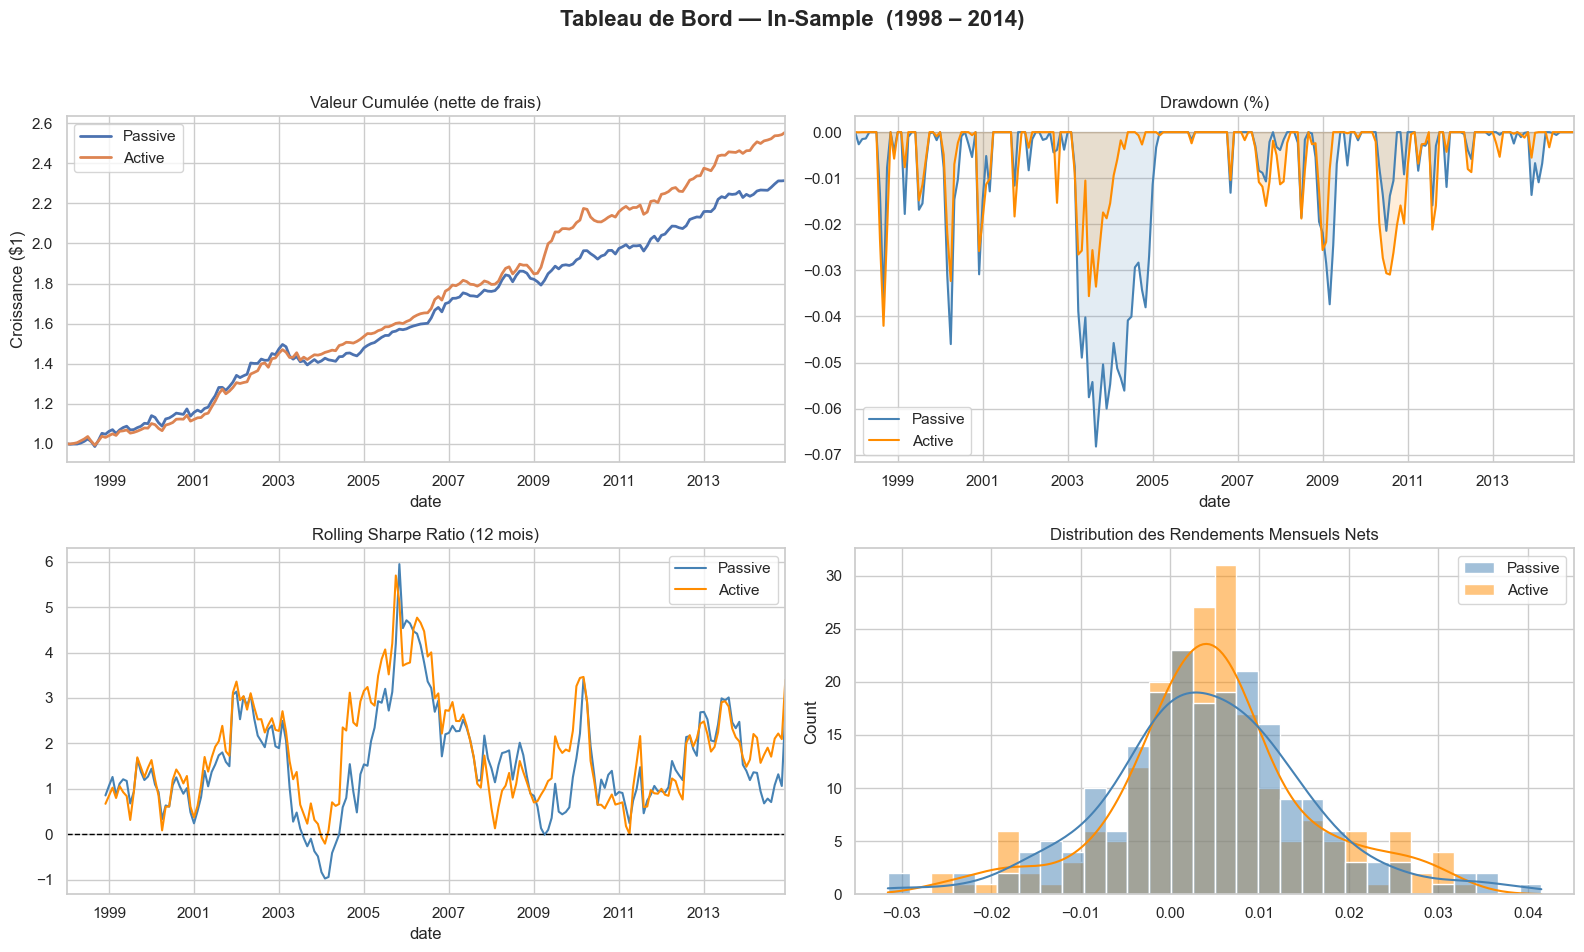

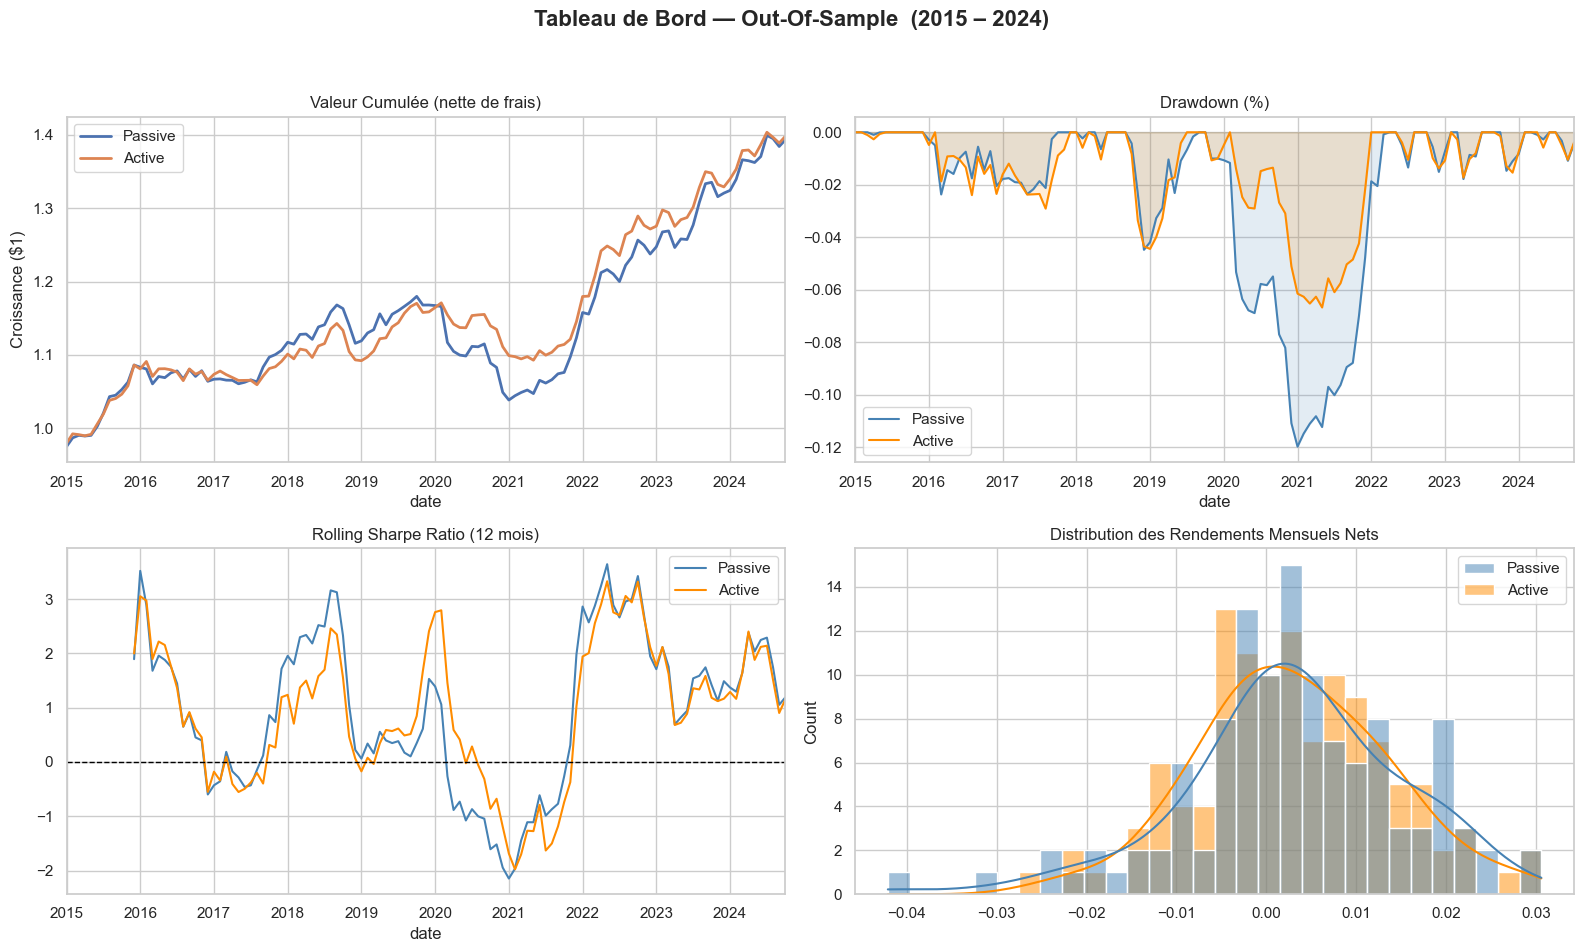

In [7]:

# =============================================================
# 8. DASHBOARD
# FIX 4: fill_between now correctly shades each strategy's drawdown
# =============================================================
def create_dashboard(df_subset, period_name):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'Tableau de Bord — {period_name}', fontsize=16, fontweight='bold')

    # --- Cumulative NAV ---
    (1 + df_subset[['Passive', 'Active']]).cumprod().plot(ax=axes[0, 0], linewidth=2)
    axes[0, 0].set_title('Valeur Cumulée (nette de frais)')
    axes[0, 0].set_ylabel('Croissance ($1)')

    # --- Drawdown (FIX 4) ---
    colors = {'Passive': 'steelblue', 'Active': 'darkorange'}
    for col in ['Passive', 'Active']:
        cum   = (1 + df_subset[col]).cumprod()
        dd    = (cum - cum.cummax()) / cum.cummax()
        dd.plot(ax=axes[0, 1], label=col, linewidth=1.5, color=colors[col])
        axes[0, 1].fill_between(df_subset.index, 0, dd,
                                alpha=0.15, color=colors[col])
    axes[0, 1].set_title('Drawdown (%)')
    axes[0, 1].legend()

    # --- Rolling Sharpe ---
    for col in ['Passive', 'Active']:
        roll_ret   = df_subset[col].rolling(12).mean() * 12
        roll_vol   = df_subset[col].rolling(12).std()  * np.sqrt(12)
        roll_sharpe = roll_ret / roll_vol
        roll_sharpe.plot(ax=axes[1, 0], label=col, linewidth=1.5, color=colors[col])
    axes[1, 0].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[1, 0].set_title('Rolling Sharpe Ratio (12 mois)')
    axes[1, 0].legend()

    # --- Return distribution ---
    sns.histplot(df_subset[['Passive', 'Active']], kde=True, bins=30, alpha=0.5,
                 ax=axes[1, 1], palette=list(colors.values()))
    axes[1, 1].set_title('Distribution des Rendements Mensuels Nets')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

create_dashboard(df_is,  "In-Sample  (1998 – 2014)")
create_dashboard(df_oos, "Out-Of-Sample  (2015 – 2024)")


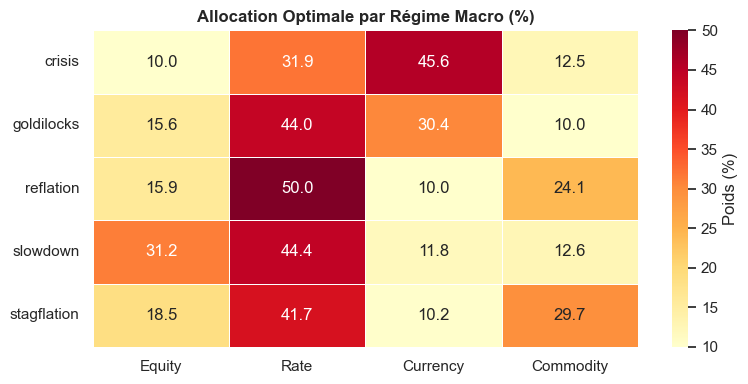

In [8]:

# =============================================================
# 9. ALLOCATION CONTEXTUELLE — HEATMAP
# =============================================================
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    opt_weights_df * 100,
    annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Poids (%)'}
)
ax.set_title('Allocation Optimale par Régime Macro (%)', fontweight='bold')
plt.tight_layout()
plt.show()